In [1]:
import csv, ast, pandas as pd, numpy as np

csv_path = "trial_results.csv"

# Load and filter rows in range
with open(csv_path, newline='') as f:
    reader = list(csv.reader(f))
    header = reader[0]
    rows = reader[1:]

selected_rows = [row for row in rows if row and row[0].isdigit() and 168 <= int(row[0]) <= 599]

df = pd.DataFrame(selected_rows, columns=header)

# Convert numeric columns
numeric_cols = ["trial_id", "thalamus_threshold", "dopamine", "dopamine_0", "scale_DNF"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Initialize counts
df["healthy_selected"] = 0
df["unhealthy_selected"] = 0

# Parse action lists and count selections >= threshold
for i, row in df.iterrows():
    try:
        threshold = row["thalamus_threshold"]
        healthy = ast.literal_eval(row["selected_action"])
        unhealthy = ast.literal_eval(row["selected_action_0"])
        if isinstance(healthy, list):
            df.at[i, "healthy_selected"] = sum(v >= threshold for _, v in healthy)
        if isinstance(unhealthy, list):
            df.at[i, "unhealthy_selected"] = sum(v >= threshold for _, v in unhealthy)
    except Exception:
        continue

# Compute ratio (R)
df["ratio"] = df["healthy_selected"] / (df["unhealthy_selected"] + 1e-6)
df["diff"] = df["healthy_selected"] - df["unhealthy_selected"]

# Penalize trials where unhealthy >= healthy (impaired BG)
df.loc[df["diff"] <= 0, "ratio"] = 0

# Stability score
ideal_low, ideal_high = 1.2, 2.0
center = (ideal_low + ideal_high) / 2
df["stability_score"] = np.exp(-((df["ratio"] - center) ** 2) / 0.3) * (df["healthy_selected"] + 1)

# Filter for trials with strong healthy selection
df_filtered = df[df["healthy_selected"] >= 24].copy()

# Top 20
df_sorted = df_filtered.sort_values(by="stability_score", ascending=False)
top20 = df_sorted.head(20)[[
    "trial_id", "ratio", "healthy_selected", "unhealthy_selected",
    "dopamine", "dopamine_0", "thalamus_threshold", "scale_DNF"
]]

print("\n=== Top 20 Strong & Stable BG Trials (Healthy >= 24) ===")
print(top20.to_string(index=False))

top20.to_csv("top20_strong_stable_trials.csv", index=False)
print("\nSaved as 'top20_strong_stable_trials.csv'")



=== Top 20 Strong & Stable BG Trials (Healthy >= 24) ===
 trial_id    ratio  healthy_selected  unhealthy_selected  dopamine  dopamine_0  thalamus_threshold  scale_DNF
      344 1.388889                25                  18       1.2        0.10                 0.4        0.9
      391 1.411765                24                  17       1.3        0.08                 0.4        0.8
      418 1.411765                24                  17       1.3        0.10                 0.5        0.8
      587 1.411765                24                  17       1.5        0.12                 0.5        0.9
      568 1.315789                25                  19       1.5        0.11                 0.3        0.8
      562 1.315789                25                  19       1.5        0.10                 0.5        0.8
      437 1.315789                25                  19       1.3        0.12                 0.3        0.9
      175 1.333333                24                  18      

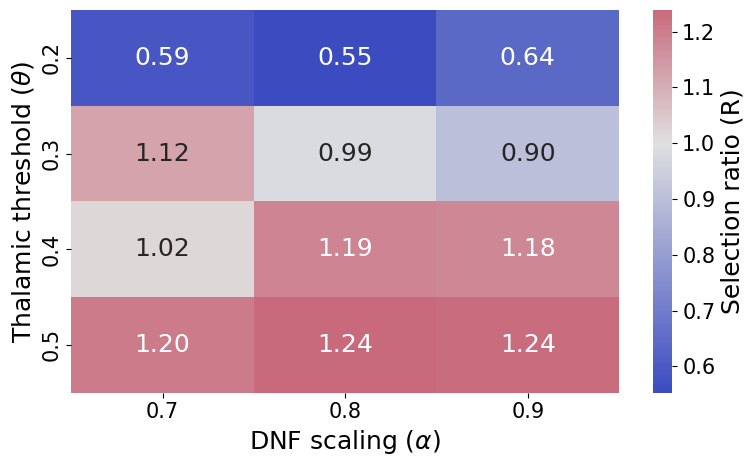

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.linewidth": 0.8
})

# Round grid params for cleaner labels
df_filtered["thalamus_threshold"] = df_filtered["thalamus_threshold"].round(2)
df_filtered["scale_DNF"] = df_filtered["scale_DNF"].round(2)

# Average ratio per (theta, alpha)
heatmap_df = (
    df_filtered
    .groupby(["thalamus_threshold", "scale_DNF"])["ratio"]
    .mean()
    .reset_index()
)

# Pivot
pivot = heatmap_df.pivot(
    index="thalamus_threshold",
    columns="scale_DNF",
    values="ratio"
).sort_index(ascending=True)

# Colormap
cmap_div = LinearSegmentedColormap.from_list(
    "cb_div",
    ["#3B4CC0", "#E0E0E0", "#B40426"],
    N=256
)

vmin = float(pivot.min().min())
vmax = float(pivot.max().max())

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap_div,
    center=1.0,
    vmin=vmin, vmax=vmax,
    cbar_kws={"label": "Selection ratio (R)"}
)
plt.xlabel(r"DNF scaling ($\alpha$)")
plt.ylabel(r"Thalamic threshold ($\theta$)")
plt.tight_layout()
plt.savefig("ratio_heatmap_theta_alpha.png", dpi=300, bbox_inches="tight")
plt.show()

pivot.to_csv("ratio_grid_theta_alpha.csv", float_format="%.2f")


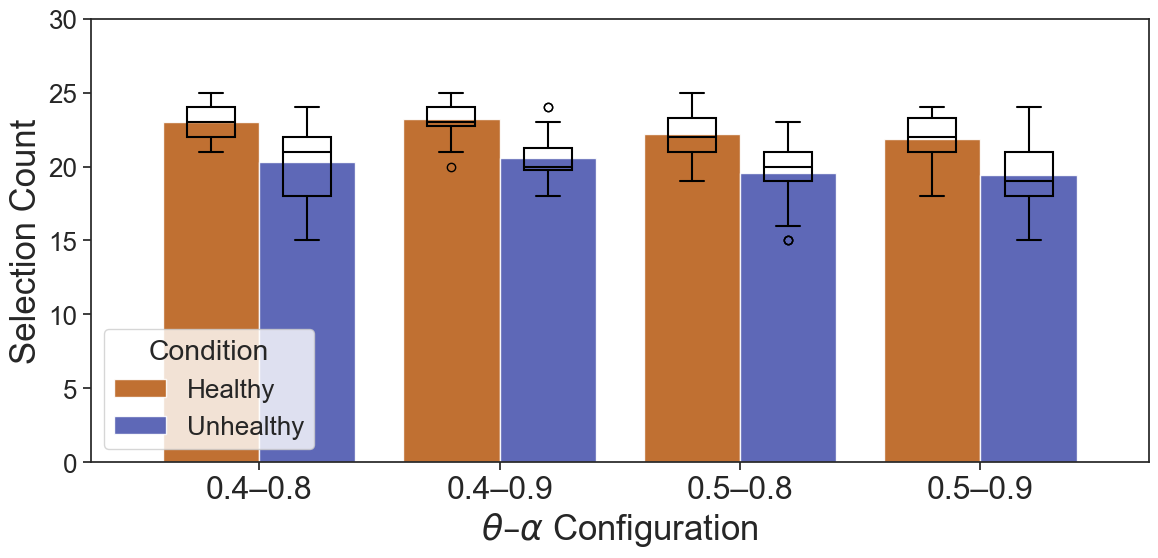

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# finding top 4 (theta, alpha) combos by mean stability score

group = df.groupby(["thalamus_threshold", "scale_DNF"]).agg({
    "healthy_selected": "mean",
    "unhealthy_selected": "mean",
    "stability_score": "mean"
}).reset_index()

top_combos = group.sort_values("stability_score", ascending=False).head(4)

# Format combo labels
top_combos["combo"] = (
    top_combos["thalamus_threshold"].map(lambda x: f"{x:.2f}".rstrip("0").rstrip(".")) + "–" +
    top_combos["scale_DNF"].map(lambda x: f"{x:.2f}".rstrip("0").rstrip("."))
)

# >>> THE FIX: define x_labels here, before plotting <<<
x_labels = top_combos["combo"].tolist()

# Filter df to only these combos
df_top = df.merge(
    top_combos[["thalamus_threshold", "scale_DNF", "combo"]],
    on=["thalamus_threshold", "scale_DNF"],
    how="inner"
)

# Melt for seaborn
df_melt = df_top.melt(
    id_vars=["combo"],
    value_vars=["healthy_selected", "unhealthy_selected"],
    var_name="Condition",
    value_name="Selection"
)
df_melt["Condition"] = df_melt["Condition"].map({
    "healthy_selected": "Healthy",
    "unhealthy_selected": "Unhealthy"
})
########
# PLOT #
########
sns.set_theme(style="ticks", font_scale=1.7)
plt.figure(figsize=(12, 6))

palette = {
    "Healthy": "#d55e00",
    "Unhealthy": "#3b4cc0"
}

bar_width = 0.35
x = np.arange(len(x_labels))

# Bar plot
sns.barplot(
    data=df_melt,
    x="combo", y="Selection",
    hue="Condition",
    palette=palette,
    errorbar=None,
    alpha=0.9,
    edgecolor=None,
    order=x_labels   # ensure consistent ordering with boxplots
)

ax = plt.gca()

# Manual centered boxplots
healthy_box_data = []
unhealthy_box_data = []
for combo in x_labels:
    subset = df_melt[df_melt["combo"] == combo]
    healthy_box_data.append(subset[subset["Condition"] == "Healthy"]["Selection"])
    unhealthy_box_data.append(subset[subset["Condition"] == "Unhealthy"]["Selection"])

ax.boxplot(
    healthy_box_data,
    positions=x - bar_width/2 - 0.025,
    widths=0.20,
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color="black", linewidth=1.5),
)

ax.boxplot(
    unhealthy_box_data,
    positions=x + bar_width/2 + 0.025,
    widths=0.20,
    patch_artist=True,
    boxprops=dict(facecolor="none", edgecolor="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    medianprops=dict(color="black", linewidth=1.5),
)

# style
ax.set_ylim(0, 30)
ax.set_xlabel(r"$\theta$–$\alpha$ Configuration", fontsize=25)
ax.set_ylabel("Selection Count", fontsize=25)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=23)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Condition")

plt.tight_layout()
plt.savefig("top_combos_bar_box.png", dpi=300, bbox_inches="tight")
plt.show()


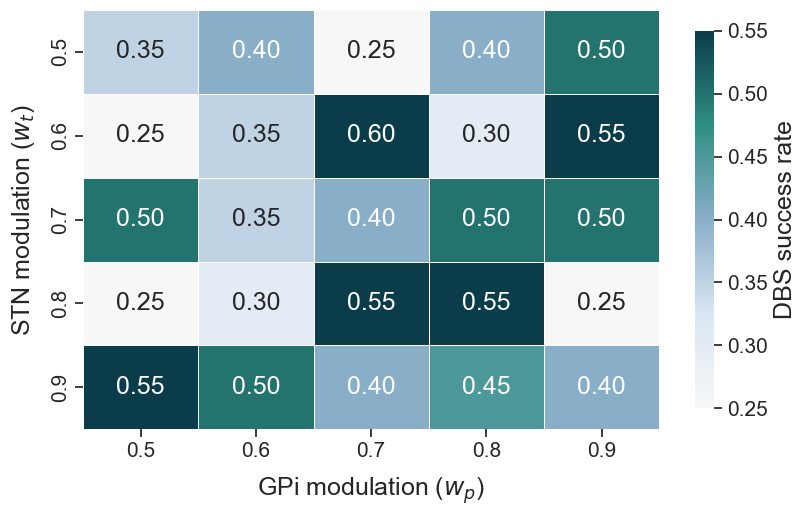

TOP DBS PARAMETER PAIR:
wp = 0.70, wt = 0.60
successes = 12/20  (rate = 0.60)


In [4]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "axes.linewidth": 0.8
})

csv_path = "dbs_trials.csv"
df_dbs = pd.read_csv(csv_path)

# numeric conversion
for col in ["trial_id", "thalamus_threshold", "wp_d", "wt_d"]:
    df_dbs[col] = pd.to_numeric(df_dbs[col], errors="coerce")
df_dbs = df_dbs.dropna(subset=["trial_id", "thalamus_threshold", "wp_d", "wt_d"]).copy()

# initialize columns
df_dbs["healthy_selected"] = 0
df_dbs["unhealthy_selected"] = 0
df_dbs["dbs_selected"] = 0

def parse_list(cell):
    try:
        parsed = ast.literal_eval(cell)
        if isinstance(parsed, dict):
            for key in parsed:
                if isinstance(parsed[key], list):
                    return parsed[key]
            return []
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

# Count saliences >= theta
for i, row in df_dbs.iterrows():
    theta = float(row["thalamus_threshold"])
    healthy_list = parse_list(row["selected_action"])
    unhealthy_list = parse_list(row["selected_action_0"])
    dbs_list = parse_list(row["selected_action_d"])

    healthy_vals = [val for (_, val) in healthy_list]
    unhealthy_vals = [val for (_, val) in unhealthy_list]
    dbs_vals = [val for (_, val) in dbs_list]

    df_dbs.at[i, "healthy_selected"]   = sum(v >= theta for v in healthy_vals)
    df_dbs.at[i, "unhealthy_selected"] = sum(v >= theta for v in unhealthy_vals)
    df_dbs.at[i, "dbs_selected"]       = sum(v >= theta for v in dbs_vals)

# DBS success criterion
df_dbs["dbs_success"] = df_dbs["dbs_selected"] > df_dbs["unhealthy_selected"]

# Round wp/wt
df_dbs["wp"] = df_dbs["wp_d"].round(2)
df_dbs["wt"] = df_dbs["wt_d"].round(2)

# aggregate per (wt, wp) pairs
agg = (
    df_dbs.groupby(["wt", "wp"])
      .agg(
          successes=("dbs_success", "sum"),
          total=("dbs_success", "size")
      )
      .reset_index()
)
agg["success_rate"] = agg["successes"] / agg["total"]

pivot = agg.pivot(index="wt", columns="wp", values="success_rate").sort_index()

# colormap specific chosen
cmap_custom = LinearSegmentedColormap.from_list(
    "dbs_richer",
    ["#f7f7f7", "#d9e6f2", "#8aaec9", "#2f8f83", "#0b3c49"],
    N=256
)

vals = pivot.to_numpy().ravel()
vals = vals[~np.isnan(vals)]
vmin = np.percentile(vals, 5)
vmax = np.percentile(vals, 95)

# plot
plt.figure(figsize=(8.5, 5.5))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap=cmap_custom,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "DBS success rate", "shrink": 0.9}
)
ax.set_xlabel("GPi modulation ($w_p$)", labelpad=10)
ax.set_ylabel("STN modulation ($w_t$)", labelpad=10)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("dbs_success_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# Best pair
best = agg.sort_values(["success_rate", "successes"], ascending=False).iloc[0]
print("TOP DBS PARAMETER PAIR:")
print(f"wp = {best['wp']:.2f}, wt = {best['wt']:.2f}")
print(f"successes = {int(best['successes'])}/{int(best['total'])}  (rate = {best['success_rate']:.2f})")


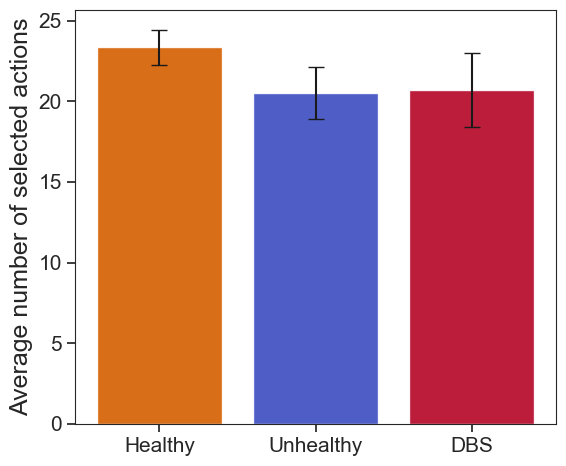

,healthy_selected,unhealthy_selected,dbs_selected
count,20.000000,20.00000,20.000000
mean,23.350000,20.50000,20.700000
std,1.089423,1.60591,2.273416
min,22.000000,18.00000,17.000000
25%,22.750000,19.00000,19.750000
50%,23.000000,21.00000,21.000000
75%,24.000000,22.00000,22.000000
max,25.000000,23.00000,24.000000


In [5]:
import matplotlib.pyplot as plt

# Filter df_dbs to best DBS parameter pair 
wp_target = 0.70
wt_target = 0.60

df_pair = df_dbs[
    (df_dbs["wp"] == wp_target) &
    (df_dbs["wt"] == wt_target)
].copy()

# === Means and stds ===
means_pair = {
    "Healthy":   df_pair["healthy_selected"].mean(),
    "Unhealthy": df_pair["unhealthy_selected"].mean(),
    "DBS":       df_pair["dbs_selected"].mean()
}
stds_pair = {
    "Healthy":   df_pair["healthy_selected"].std(),
    "Unhealthy": df_pair["unhealthy_selected"].std(),
    "DBS":       df_pair["dbs_selected"].std()
}

labels = list(means_pair.keys())
mean_vals = list(means_pair.values())
std_vals = list(stds_pair.values())

palette = {
    "Healthy":   "#d55e00",
    "Unhealthy": "#3b4cc0",
    "DBS":       "#B40426"
}
colors = [palette[label] for label in labels]

plt.figure(figsize=(6, 5))
plt.bar(
    labels,
    mean_vals,
    yerr=std_vals,
    color=colors,
    capsize=6,
    alpha=0.9
)
plt.ylabel("Average number of selected actions")
plt.tight_layout()
plt.savefig("avg_action_selection_best_dbs_pair.png", dpi=300)
plt.show()

df_pair[["healthy_selected", "unhealthy_selected", "dbs_selected"]].describe()
